<a href="https://colab.research.google.com/github/sebastianczerwinski2/house_prices_prediction/blob/main/house_prices_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import joblib
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error



In [24]:
path = kagglehub.dataset_download("vikrishnan/boston-house-prices")

print("Path to dataset files:", path)

kolumny = ['crime_rate', 'residental_lands_rate', 'industrial_rate', 'river', 'air_quality_rate', 'number_of_rooms_rate',
           'age_town_rate', 'distance_to_work_rate', 'highways_dis_rate', 'tax_rate', 'teachers_rate', 'black_pop_index','lower_status_rate', 'median_house_prices']

data = pd.read_csv("../kaggle/input/boston-house-prices/housing.csv", header=None, sep=r'\s+', names=kolumny)

data = data.drop(columns=['black_pop_index'])

Using Colab cache for faster access to the 'boston-house-prices' dataset.
Path to dataset files: /kaggle/input/boston-house-prices


In [21]:
X = data.drop(columns=['median_house_prices'])

y = data['median_house_prices']

X_train, X_test, y_train, y_test = train_test_split(X,y, train_size=0.8, test_size=0.2, random_state=42)

model = LinearRegression()
#Dobieranie odpowiednich wag
model.fit(X_train,y_train)
#sprawdzamy jak poradził sobie nasz model
predictions = model.predict(X_test)

print("Przewidywania modelu (w tys. $):")
print(np.round(predictions[:5], 2))

print("\nPrawdziwe ceny tych samych dzielnic (w tys. $):")
print(y_test[:5].values)



Przewidywania modelu (w tys. $):
[28.96 36.29 14.1  25.03 17.6 ]

Prawdziwe ceny tych samych dzielnic (w tys. $):
[23.6 32.4 13.6 22.8 16.1]


In [5]:
mean_err = np.mean(abs(predictions[:] - y_test[:]))
#średni błąd naszego modelu regresji liniowej dla każdej predykcji
print(f"średni błąd naszego modelu regresji liniowej dla każdej predykcji w tyś \033[1m{round(mean_err,3)}$\033[0m")

średni błąd naszego modelu regresji liniowej dla każdej predykcji w tyś 3.111$


In [6]:
#Sprawdzamy jak bardzo poprawią się nasze wyniki po zmianie na Las losowy z prostej regresji

model_las = RandomForestRegressor()

model_las.fit(X_train,y_train)

predictions_las = model_las.predict(X_test)

mean_err_las = mean_absolute_error(predictions_las,y_test)

print(f"średni błąd naszego modelu lasu losowego dla każdej predykcji w tyś \033[1m{round(mean_err_las,3)}$\033[0m")

średni błąd naszego modelu lasu losowego dla każdej predykcji w tyś 2.086$


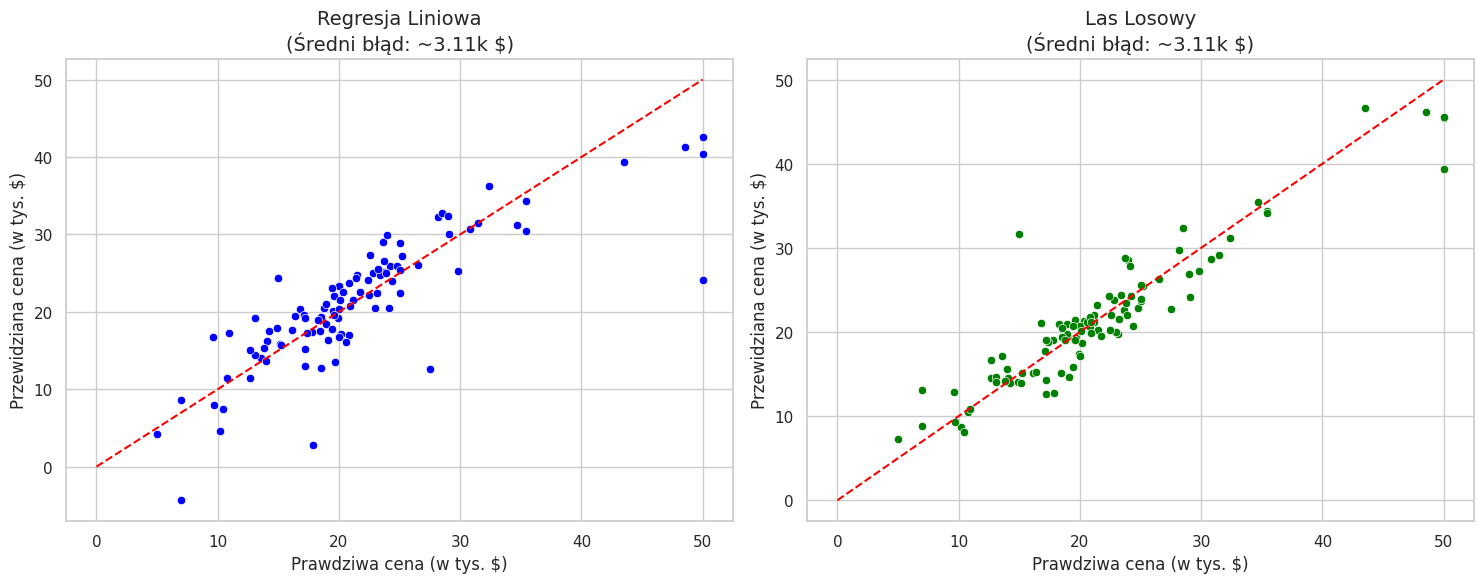

In [7]:
#Przedstawiamy dane na wykresach

sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(1,2,figsize=(15,6))
sns.scatterplot(x=y_test, y=predictions, ax=ax[0], color='blue')
max_val_lin = max(max(y_test), max(predictions))
ax[0].plot([0,max_val_lin],[0,max_val_lin], color='red', linestyle='--')

ax[0].set_title(f"Regresja Liniowa\n(Średni błąd: ~{mean_err:.2f}k $)", fontsize=14)
ax[0].set_xlabel("Prawdziwa cena (w tys. $)", fontsize=12)
ax[0].set_ylabel("Przewidziana cena (w tys. $)", fontsize=12)

sns.scatterplot(x=y_test, y=predictions_las, ax=ax[1], color='green')
max_val_las = max(max(y_test), max(predictions_las))
ax[1].plot([0,max_val_lin],[0,max_val_lin], color='red', linestyle='--')

ax[1].set_title(f"Las Losowy\n(Średni błąd: ~{mean_err:.2f}k $)", fontsize=14)
ax[1].set_xlabel("Prawdziwa cena (w tys. $)", fontsize=12)
ax[1].set_ylabel("Przewidziana cena (w tys. $)", fontsize=12)

plt.tight_layout()
plt.show()

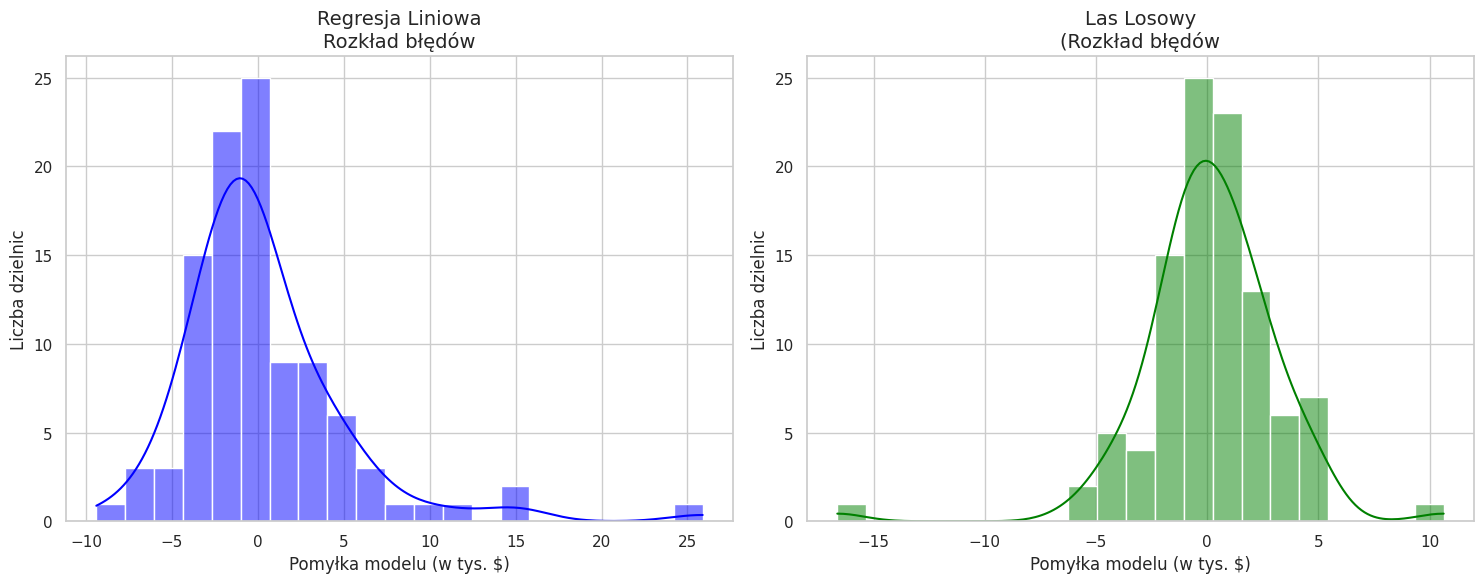

In [8]:
#Pokażemy też rozkład błędów dla naszych modeli
fig, ax = plt.subplots(1,2,figsize=(15,6))

err_lin = y_test - predictions
err_las = y_test - predictions_las

sns.histplot(err_lin, ax=ax[0], color='blue', kde=True)

ax[0].set_title(f"Regresja Liniowa\nRozkład błędów", fontsize=14)
ax[0].set_xlabel("Pomyłka modelu (w tys. $)", fontsize=12)
ax[0].set_ylabel("Liczba dzielnic", fontsize=12)

sns.histplot(err_las, ax=ax[1], color='green', kde=True)

ax[1].set_title(f"Las Losowy\n(Rozkład błędów", fontsize=14)
ax[1].set_xlabel("Pomyłka modelu (w tys. $)", fontsize=12)
ax[1].set_ylabel("Liczba dzielnic", fontsize=12)

plt.tight_layout()
plt.show()

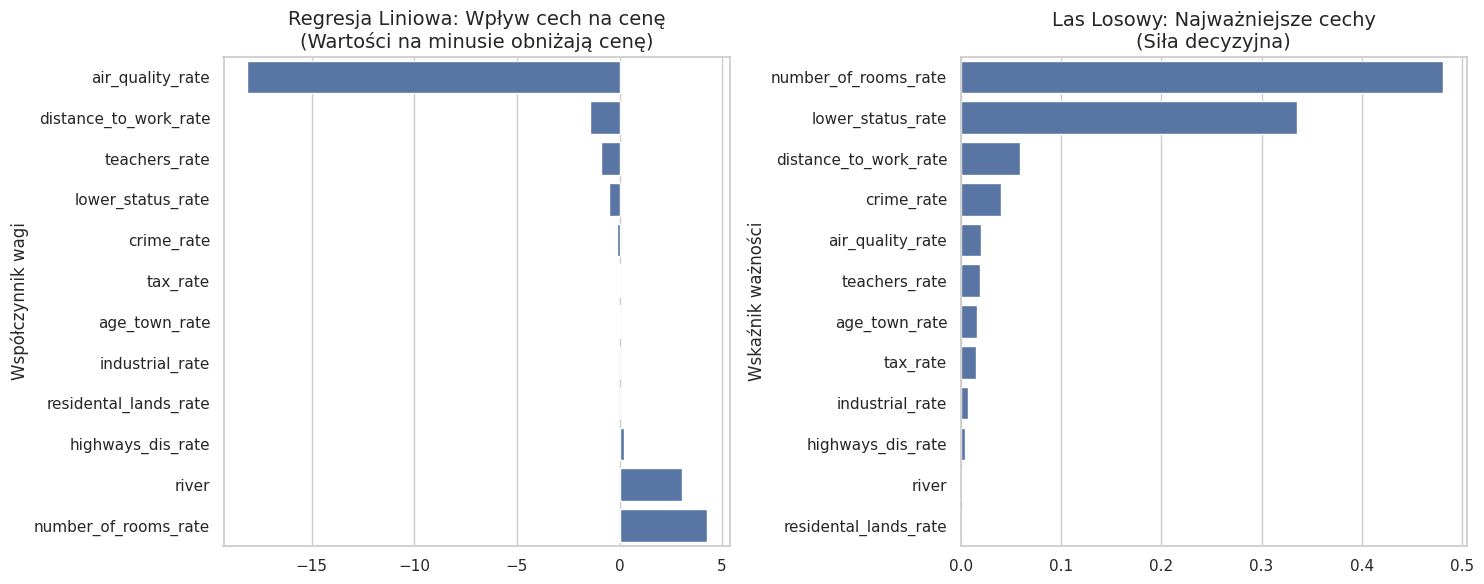

In [22]:
#Najważniejsze cechy dla każdego z modeli

fig, ax = plt.subplots(1,2, figsize=(15,6))

feature_names = X.columns

coef_lin = pd.DataFrame({'Cecha': feature_names, 'Wpływ': model.coef_})
coef_lin = coef_lin.sort_values(by='Wpływ', ascending=True)

sns.barplot(x='Wpływ', y='Cecha', data=coef_lin, ax=ax[0])
ax[0].set_title("Regresja Liniowa: Wpływ cech na cenę\n(Wartości na minusie obniżają cenę)", fontsize=14)
ax[0].set_xlabel("")
ax[0].set_ylabel("Współczynnik wagi", fontsize=12)

imp_df = pd.DataFrame({'Cecha': feature_names, 'Ważność': model_las.feature_importances_})
imp_df = imp_df.sort_values(by='Ważność', ascending=False)

sns.barplot(x='Ważność', y='Cecha', data=imp_df, ax=ax[1])
ax[1].set_title("Las Losowy: Najważniejsze cechy\n(Siła decyzyjna)", fontsize=14)
ax[1].set_xlabel("")
ax[1].set_ylabel("Wskaźnik ważności", fontsize=12)

plt.tight_layout()
plt.show()

Ciekawe jest to że nie wszystkie parametry tak samo wpływają na wynik przy tych dwóch modelach. Dla regresji jakość powietrza jest najważniejsza, a dla lasu losowego nie ma aż tak dużego wpływu.

In [23]:
joblib.dump(model_las, 'model_cen_mieszkan.pkl')

['model_cen_mieszkan.pkl']